In [1]:
import random
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler, LabelEncoder, MinMaxScaler
from sklearn import svm
from sklearn.model_selection import StratifiedShuffleSplit, GridSearchCV
from sklearn.metrics import f1_score, recall_score, precision_score, confusion_matrix, make_scorer
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from joblib import load, dump

In [2]:
testsize=0.4
file = r"D:/Research/Mineral identifier ann IISER Mohali/new random comp generator/GEOROC data/processed minerals/molar tables/new data/compiled9_2.xlsx"
# file = r"/home/avi/Documents/Research/Mineral identifier ann IISER Mohali/new random comp generator/GEOROC data/processed minerals/molar tables/new data/compiled9_2.xlsx"

In [3]:
data =pd.read_excel(file,header=0,index_col=0)

cond = (data['Mineral']=="Act/Tr") | (data['Mineral']=="Fe-Mg Amp") | (data['Mineral']=="Hbl") | (data['Mineral']=="Na-Amp")
data = data.copy()
data.loc[cond,"Mineral"] = "Amp"
data.loc[(data.Mineral == "opx") | (data.Mineral == "cpx"),"Mineral"] = "Px"

data1 = data.copy()

plt.rc('font',size=10,family='serif')
figsize=(10,10)
lw = 1

print(len(data))

47031


In [4]:
model = svm.SVC(C=1,kernel='rbf',gamma=.085,max_iter=-1,verbose=0,probability=True)
f1 = make_scorer(f1_score, average="macro")

over_metrics="weighted"
sample_metrics="micro"

# parameters = {'kernel' : ['linear','poly','rbf','sigmoid'], 'gamma':['scale','auto'],'degree': [i for i in range(1,5)]}
# parameters = {'gamma': np.arange(0,5,25e-2),'kernel' : ['linear','poly','rbf'],'degree': [i for i in range(1,4)]}
# model_test = svm.SVC()
# model = GridSearchCV(model_test, param_grid=parameters,verbose=4,scoring=f1,cv=5,n_jobs=6)


Testing for raw input data

99.86
Als: accuracy: 100.0
Amp: accuracy: 99.893
Ap: accuracy: 100.0
Bt: accuracy: 100.0
Cb: accuracy: 100.0
Cor: accuracy: 100.0
Crd: accuracy: 100.0
Fsp: accuracy: 100.0
Grt: accuracy: 100.0
Ilm: accuracy: 100.0
Mag/Hem: accuracy: 100.0
Ms: accuracy: 100.0
Ol: accuracy: 100.0
Px: accuracy: 99.214
Qz: accuracy: 100.0
Rt: accuracy: 100.0
Spl: accuracy: 100.0
St: accuracy: 100.0
Ttn: accuracy: 100.0


['Labeler_C1.lbl']

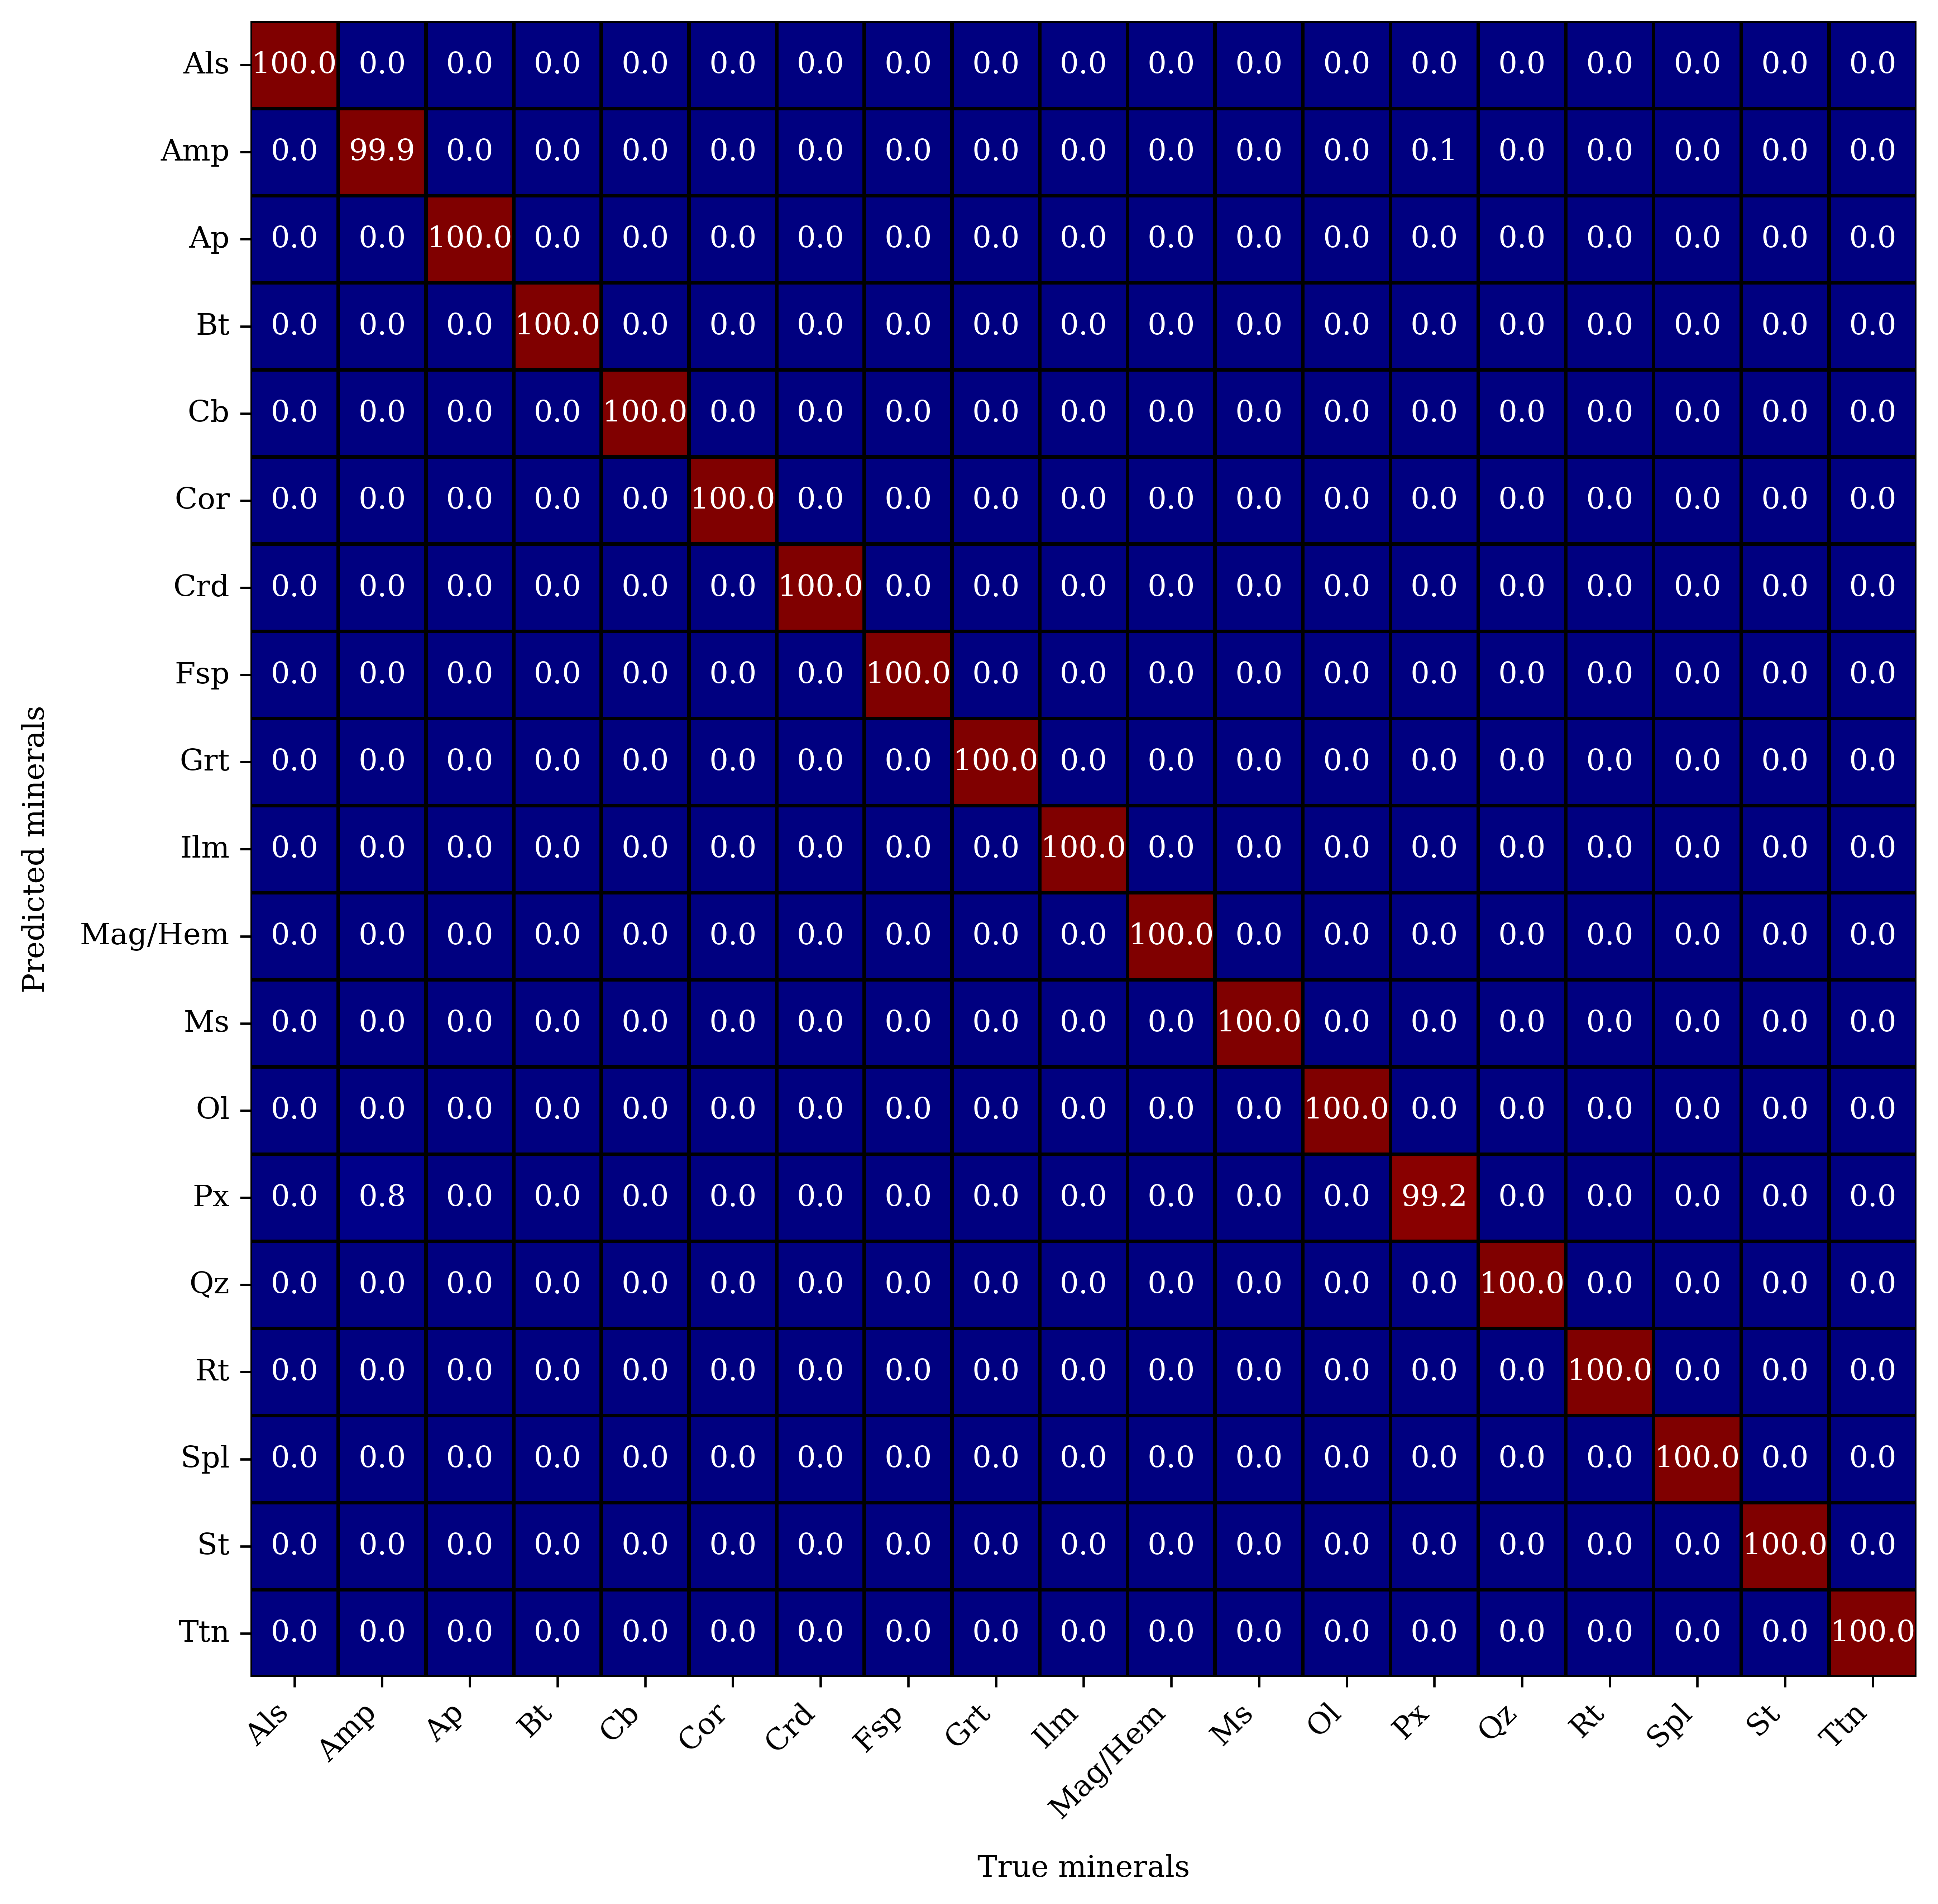

In [5]:
#%%
data = data1.copy()
# scaler = MinMaxScaler(feature_range=(-1,1))
# scaler = MinMaxScaler()
scaler = StandardScaler()
data_scaled = scaler.fit_transform(data.iloc[:,:-2])

labeler = LabelEncoder()
target = labeler.fit_transform(data['Mineral'])

minerals = len(labeler.classes_)+1
acc_table = np.zeros((minerals,14))
recall_table = np.zeros((minerals,14))
precision_table = np.zeros((minerals,14))


splitter = StratifiedShuffleSplit(n_splits=2,test_size=testsize,random_state=2)
split, split1 = splitter.split(data_scaled, target)
train_data = data_scaled[split1[0],:]
train_label = target[split1[0]]
test_data = data_scaled[split1[1],:]
test_label = target[split1[1]]

print("\nTesting for raw input data\n")

# model = svm.SVC(kernel='poly',gamma=3,degree=3,max_iter=1000000,verbose=0,probability=True)

model.fit(train_data, train_label)
pred_label = model.predict(test_data)
a = round(f1_score(test_label, pred_label, average=over_metrics),5)*100
r = round(recall_score(test_label, pred_label, average=over_metrics),5)*100
p = round(precision_score(test_label, pred_label, average=over_metrics),5)*100
acc_table[0,0] = a
precision_table[0,0] = p
recall_table[0,0] = r
print(round(a,2))
cm_raw = confusion_matrix(test_label, pred_label,normalize='true')*100
cm_raw = pd.DataFrame(cm_raw,columns = labeler.classes_,index=labeler.classes_)
plt.figure(figsize=figsize,dpi=600)
sns.heatmap(cm_raw, annot=True,cmap="jet",fmt='.1f',linewidths=lw,linecolor='black',cbar=False)
plt.xticks(rotation=45,ha='right')
plt.xlabel("True minerals",labelpad=10)
plt.ylabel("Predicted minerals",labelpad=10)
plt.savefig("SVM_C1.pdf",bbox_inches='tight')

for i in range(0,minerals-1):
    test_data1 = test_data[test_label==i]
    test_label1 = test_label[test_label==i]
    pred_label1 = model.predict(test_data1)
    a = round(f1_score(test_label1, pred_label1, average=sample_metrics),5)*100
    r = round(recall_score(test_label1, pred_label1, average=sample_metrics),5)*100
    p = round(precision_score(test_label1, pred_label1, average=sample_metrics),5)*100
    acc_table[i+1,0] = a
    precision_table[i+1,0] = p
    recall_table[i+1,0] = r
    name = labeler.inverse_transform([i])[0]
    print(f"{name}: accuracy: {a}")

# for i in range(0,m):
#     test_data1 = data_scaled[target==i]
#     test_label1 = target[target==i]
#     pred_label1 = model.predict(test_data1)
#     a = round(f1_score(test_label1, pred_label1, average="micro"),4)*100
#     acc_table[i+1,0] = a
#     name = labeler.inverse_transform([i])[0]
#     print(f"{name}: accuracy: {a}")

pred_label = model.predict(data_scaled)
test_data_df = data.copy()
test_data_df['Pred'] = labeler.inverse_transform(pred_label)
test_data_df_mismatch = test_data_df[test_data_df['Mineral'] != test_data_df['Pred']]
test_data_df_mismatch

dump(model,"SVM_C1.mdl")
dump(scaler,"Scaler_C1.scl")
dump(labeler,"Labeler_C1.lbl")

In [6]:
# model.coef_

In [7]:
# testres = model.cv_results_
# testres = pd.DataFrame(testres)
# testres.to_excel("/Users/aditya/Documents/Research/Mineral identifier ann IISER Mohali/Additional machine learning algos/SVM/SVM_gridsearch_result_raw_data.xlsx")


Testing for FeO+MnO+MgO input data

99.82
Als: accuracy: 100.0
Amp: accuracy: 99.893
Ap: accuracy: 100.0
Bt: accuracy: 100.0
Cb: accuracy: 100.0
Cor: accuracy: 100.0
Crd: accuracy: 100.0
Fsp: accuracy: 100.0
Grt: accuracy: 100.0
Ilm: accuracy: 100.0
Mag/Hem: accuracy: 100.0
Ms: accuracy: 100.0
Ol: accuracy: 100.0
Px: accuracy: 98.97500000000001
Qz: accuracy: 100.0
Rt: accuracy: 100.0
Spl: accuracy: 100.0
St: accuracy: 100.0
Ttn: accuracy: 100.0


['Labeler_C2.lbl']

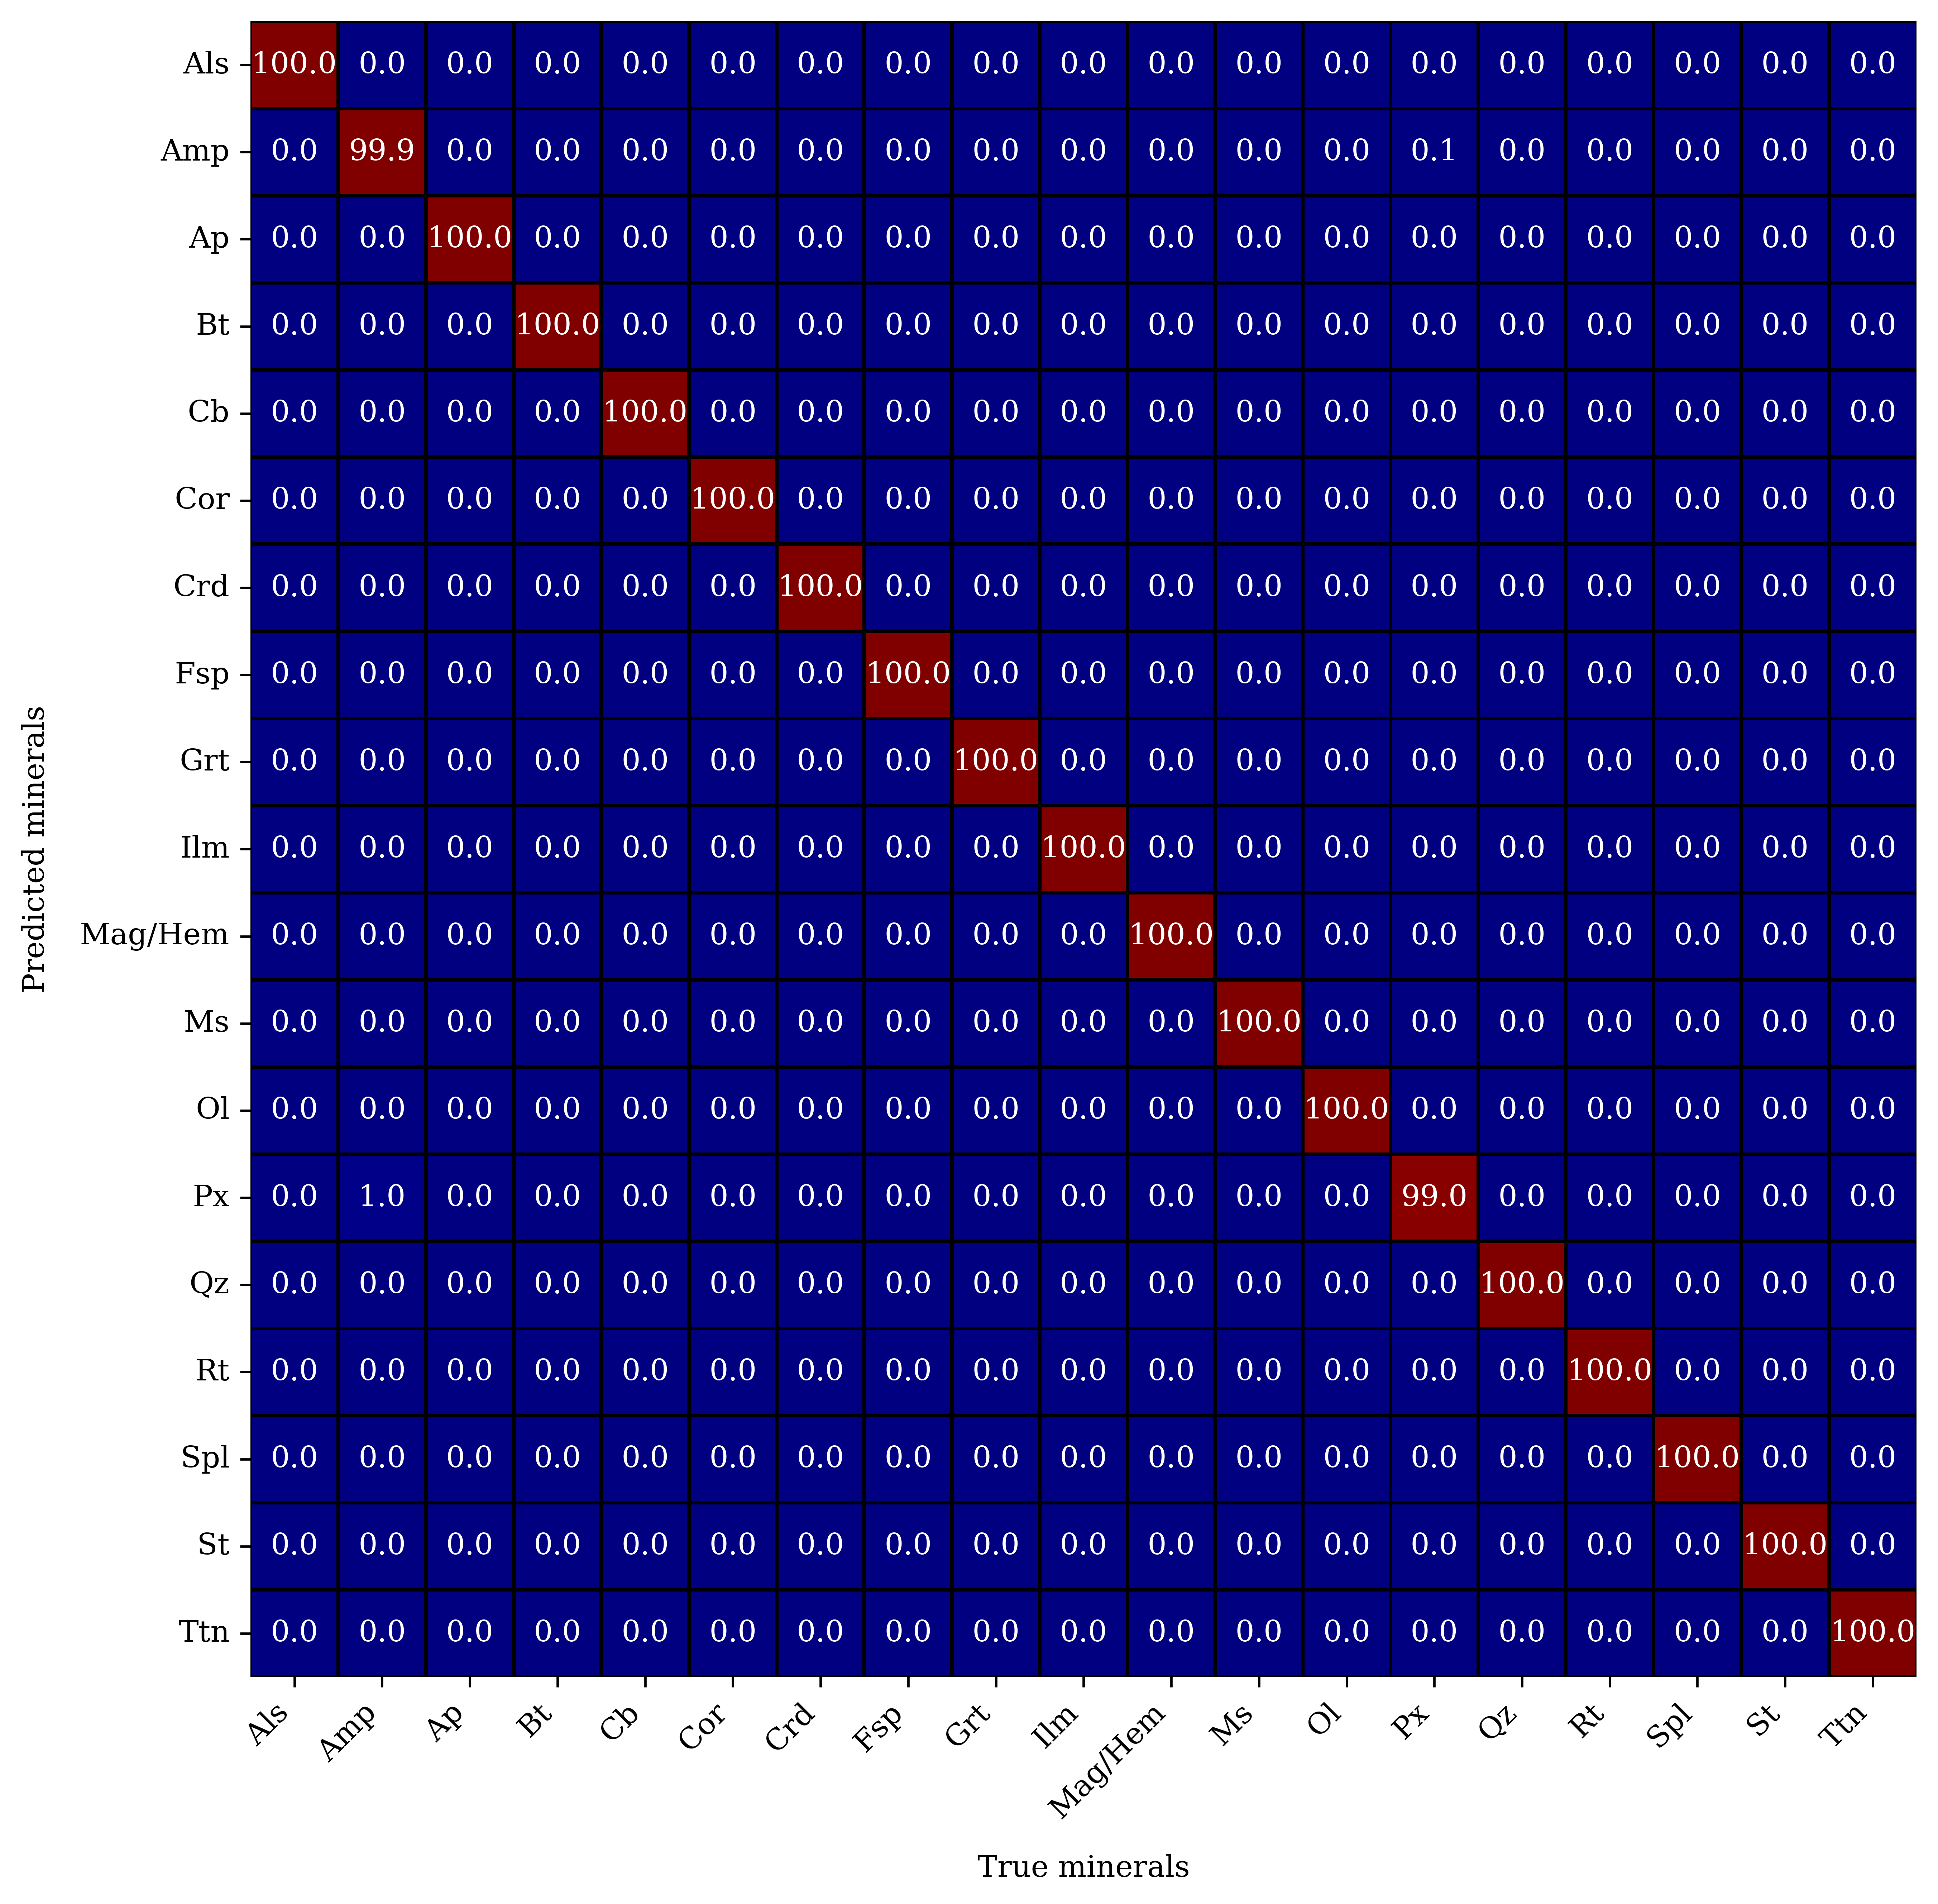

In [8]:
# data =pd.read_excel(file,header=0)

# data.loc[(data.Mineral == "opx") | (data.Mineral == "cpx"),"Mineral"] = "px"

data = data1.copy()

data['M'] = data['FeO']+data['MgO']+data['MnO']
data.pop("FeO")
data.pop("MgO")
data.pop("MnO")


data = data[['SiO2', 'TiO2', 'Al2O3', 'M', 'CaO', 'Na2O', 'K2O', 'P2O5', 'CO2', 'Mineral', 'Source']]

# data['Al/Si'] = (data["Al2O3"]-data['SiO2'])/(data['SiO2']+data['Al2O3'])

# data = data[['SiO2', 'TiO2', 'Al2O3', 'M', 'CaO', 'A', 'Al/Si',
#        'Mineral', 'Source']]
scaler = StandardScaler()
data_scaled = scaler.fit_transform(data.iloc[:,:-2])

labeler = LabelEncoder()
target = labeler.fit_transform(data['Mineral'])

splitter = StratifiedShuffleSplit(n_splits=2,test_size=testsize,random_state=2)
split, split1 = splitter.split(data_scaled, target)
train_data = data_scaled[split1[0],:]
train_label = target[split1[0]]
test_data = data_scaled[split1[1],:]
test_label = target[split1[1]]

print("\nTesting for FeO+MnO+MgO input data\n")

# model = svm.SVC(kernel='poly',degree=3,gamma=3,max_iter=1000000,verbose=0)
model.fit(train_data, train_label)
pred_label = model.predict(test_data)
a = round(f1_score(test_label, pred_label, average=over_metrics),5)*100
r = round(recall_score(test_label, pred_label, average=over_metrics),5)*100
p = round(precision_score(test_label, pred_label, average=over_metrics),5)*100
acc_table[0,1] = a
precision_table[0,1] = p
recall_table[0,1] = r
print(round(a,2))
cm_raw = confusion_matrix(test_label, pred_label,normalize='true')*100
cm_raw = pd.DataFrame(cm_raw,columns = labeler.classes_,index=labeler.classes_)
plt.figure(figsize=figsize,dpi=600)
sns.heatmap(cm_raw, annot=True,cmap="jet",fmt='.1f',linewidths=lw,linecolor='black',cbar=False)
plt.xticks(rotation=45,ha='right')
plt.xlabel("True minerals",labelpad=10)
plt.ylabel("Predicted minerals",labelpad=10)
plt.savefig("SVM_C2.pdf",bbox_inches='tight')

for i in range(0,minerals-1):
    test_data1 = test_data[test_label==i]
    test_label1 = test_label[test_label==i]
    pred_label1 = model.predict(test_data1)
    a = round(f1_score(test_label1, pred_label1, average=sample_metrics),5)*100
    r = round(recall_score(test_label1, pred_label1, average=sample_metrics),5)*100
    p = round(precision_score(test_label1, pred_label1, average=sample_metrics),5)*100
    acc_table[i+1,1] = a
    precision_table[i+1,1] = p
    recall_table[i+1,1] = r
    name = labeler.inverse_transform([i])[0]
    print(f"{name}: accuracy: {a}")

# for i in range(0,16):
#     test_data1 = data_scaled[target==i]
#     test_label1 = target[target==i]
#     pred_label1 = model.predict(test_data1)
#     a = round(f1_score(test_label1, pred_label1, average="micro"),5)*100
#     r = round(recall_score(test_label1, pred_label1, average="micro"),5)*100
#     p = round(precision_score(test_label1, pred_label1, average="micro"),5)*100
#     acc_table[i+1,1] = a
#     precision_table[i+1,1] = p
#     recall_table[i+1,1] = r
#     name = labeler.inverse_transform([i])[0]
#     print(f"{name}: accuracy: {a}")

pred_label = model.predict(data_scaled)
test_data_df = data.copy()
test_data_df['Pred'] = labeler.inverse_transform(pred_label)
test_data_df_mismatch = test_data_df[test_data_df['Mineral'] != test_data_df['Pred']]
cm = confusion_matrix(target, pred_label)
cm = pd.DataFrame(cm,columns=labeler.classes_,index=labeler.classes_)
test_data_df_mismatch

dump(model,"SVM_C2.mdl")
dump(scaler,"Scaler_C2.scl")
dump(labeler,"Labeler_C2.lbl")

In [9]:
# testres = model.cv_results_
# testres = pd.DataFrame(testres)
# testres.to_excel("/Users/aditya/Documents/Research/Mineral identifier ann IISER Mohali/Additional machine learning algos/SVM/SVM_gridsearch_result_FeO+MnO+MgO.xlsx")


Testing for FeO+MnO+MgO and Na2O+K2O input data

99.81
Als: accuracy: 100.0
Amp: accuracy: 99.893
Ap: accuracy: 100.0
Bt: accuracy: 100.0
Cb: accuracy: 100.0
Cor: accuracy: 100.0
Crd: accuracy: 100.0
Fsp: accuracy: 99.668
Grt: accuracy: 100.0
Ilm: accuracy: 100.0
Mag/Hem: accuracy: 100.0
Ms: accuracy: 100.0
Ol: accuracy: 100.0
Px: accuracy: 98.97500000000001
Qz: accuracy: 100.0
Rt: accuracy: 100.0
Spl: accuracy: 100.0
St: accuracy: 100.0
Ttn: accuracy: 100.0


['Labeler_C3.lbl']

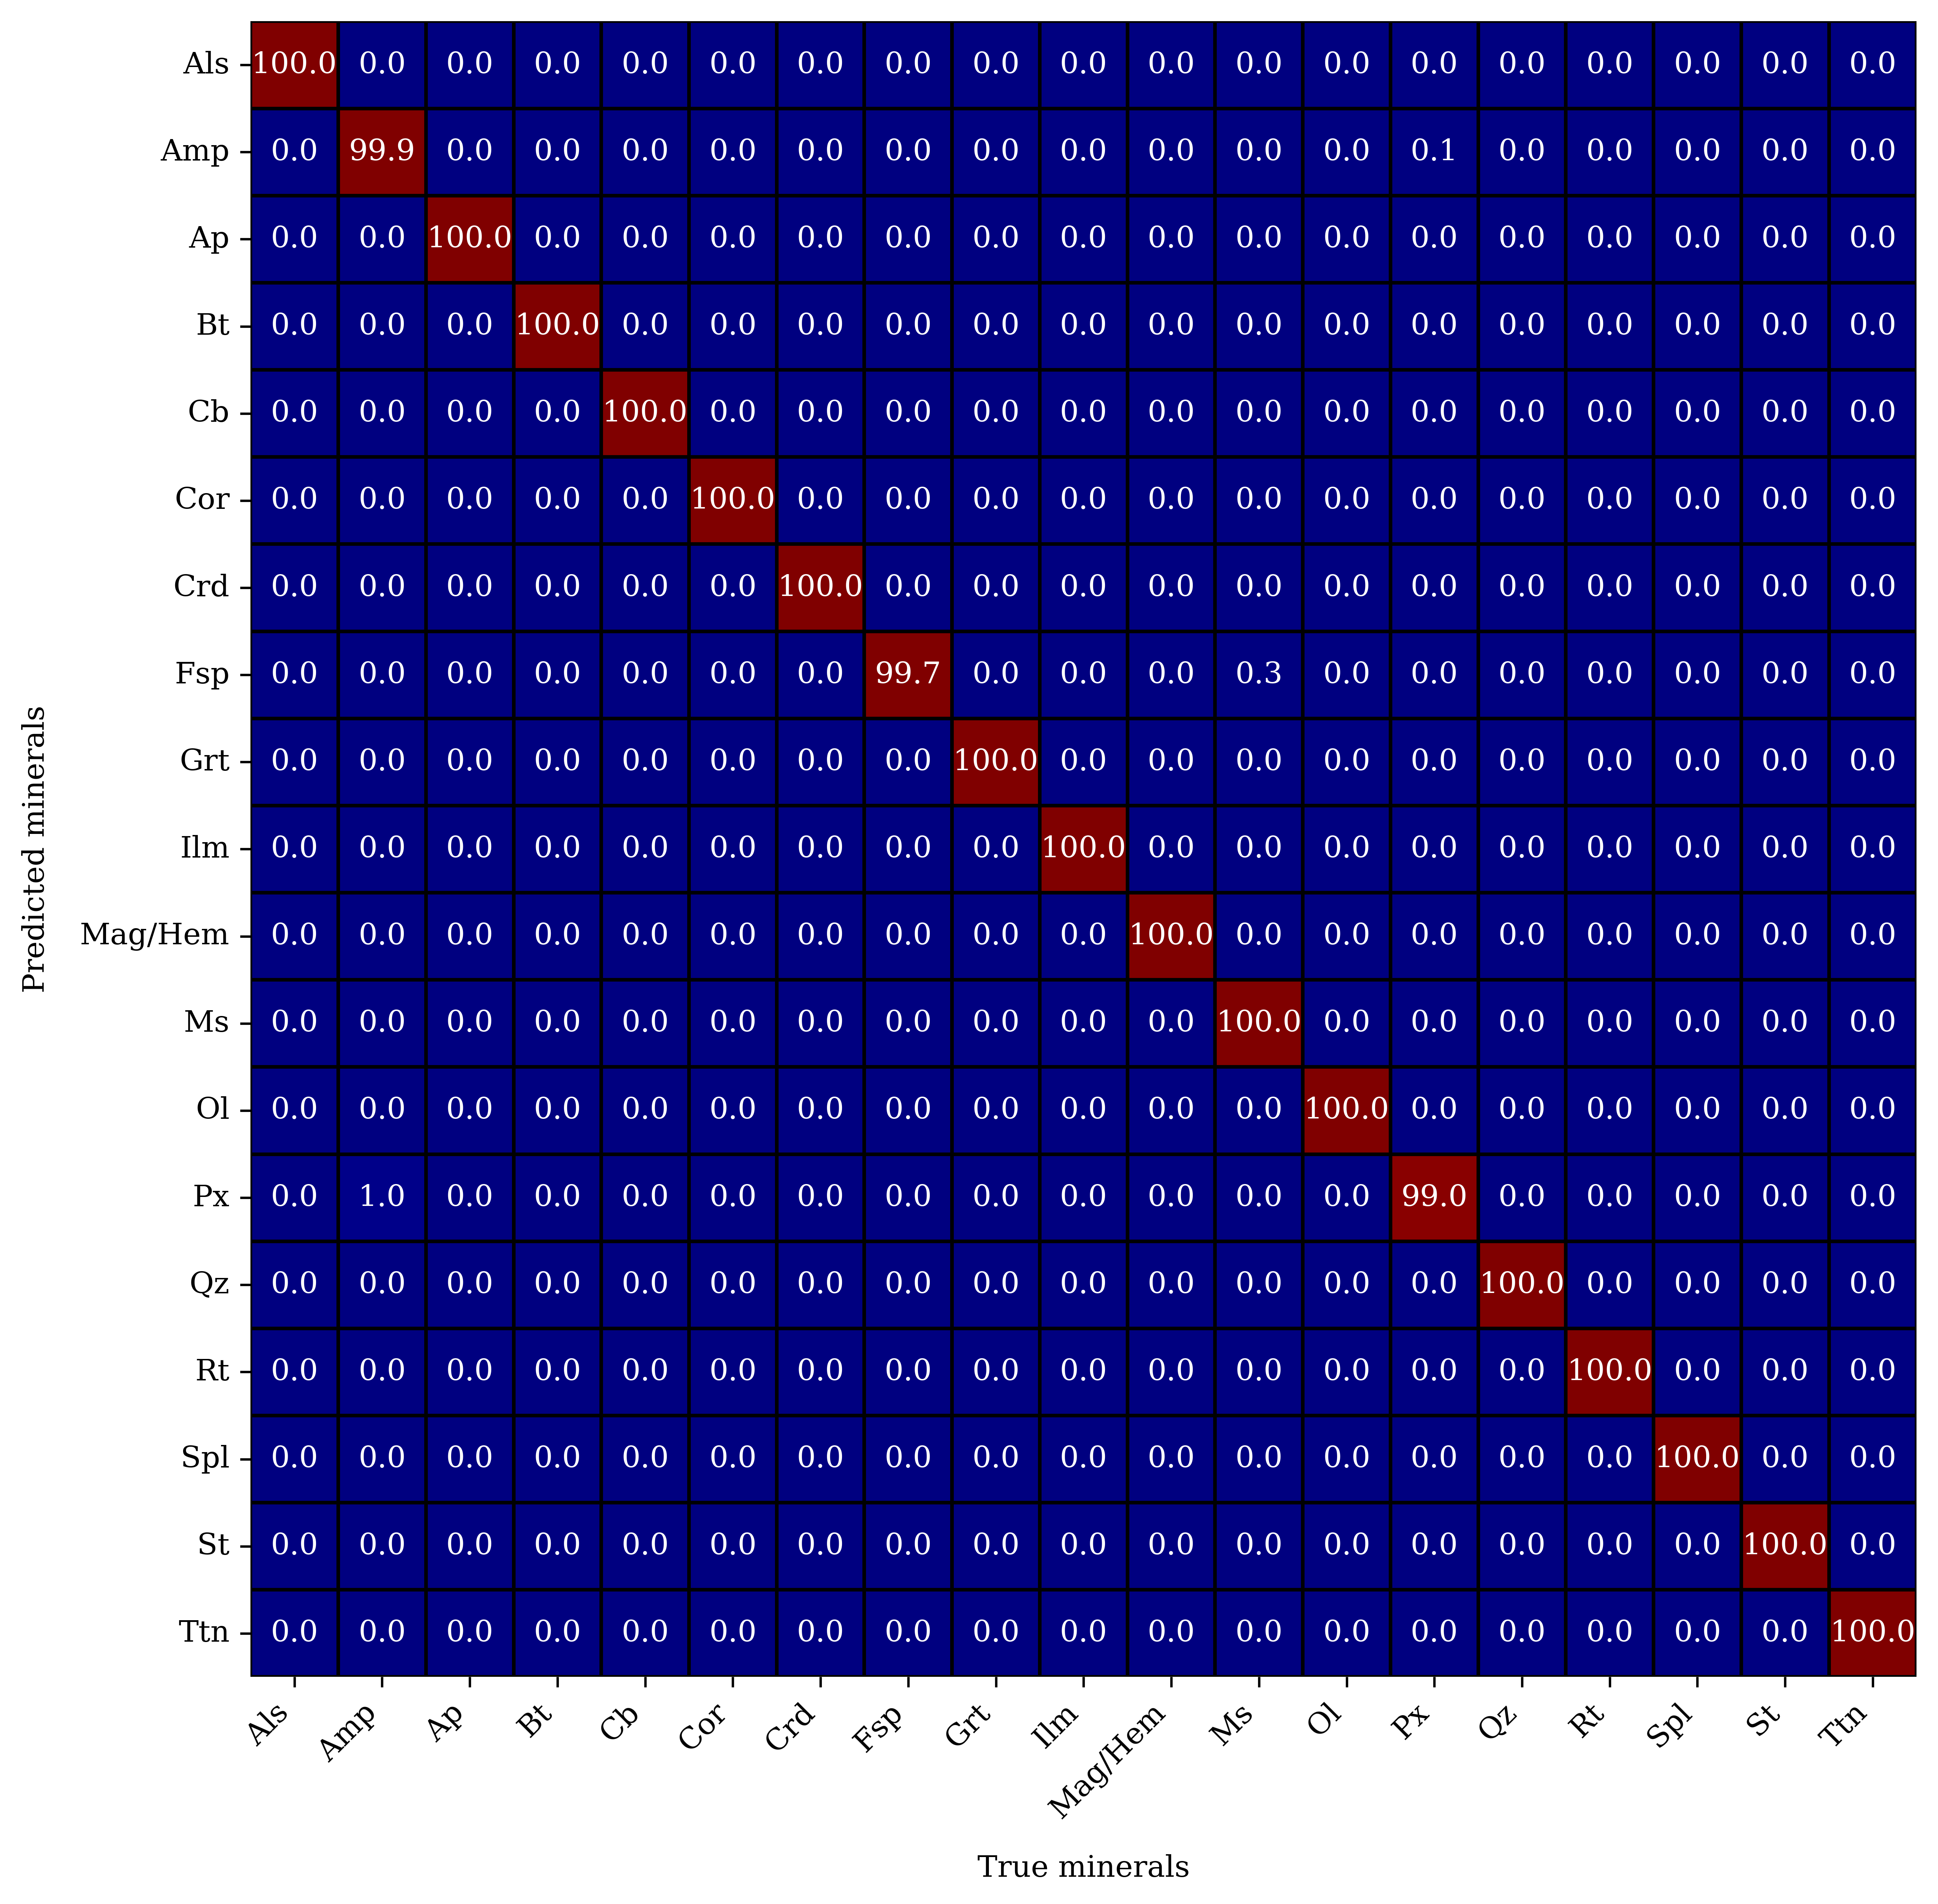

In [10]:
# data =pd.read_excel(file,header=0)

# data.loc[(data.Mineral == "opx") | (data.Mineral == "cpx"),"Mineral"] = "px"
data = data1.copy()
data['M'] = data['FeO']+data['MgO']+data['MnO']#+data['CaO']
data.pop("FeO")
data.pop("MgO")
data.pop("MnO")
# data.pop("CaO")

data['A'] = data["K2O"]+data["Na2O"]
data.pop("K2O")
data.pop("Na2O")
data = data[['SiO2', 'TiO2', 'Al2O3', 'M', 'CaO', 'A', 'P2O5', 'CO2', 'Mineral', 'Source']]

scaler = StandardScaler()
data_scaled = scaler.fit_transform(data.iloc[:,:-2])

labeler = LabelEncoder()
target = labeler.fit_transform(data['Mineral'])

splitter = StratifiedShuffleSplit(n_splits=2,test_size=testsize,random_state=2)
split, split1 = splitter.split(data_scaled, target)
train_data = data_scaled[split1[0],:]
train_label = target[split1[0]]
test_data = data_scaled[split1[1],:]
test_label = target[split1[1]]

print("\nTesting for FeO+MnO+MgO and Na2O+K2O input data\n")

# model = svm.SVC(kernel='poly',degree=3,gamma=3,max_iter=1000000,verbose=0)
model.fit(train_data, train_label)
pred_label = model.predict(test_data)
# a = round(f1_score(test_label, pred_label, average="macro"),4)*100
# print(round(a,2))
# acc_table[0,2] = a

a = round(f1_score(test_label, pred_label, average=over_metrics),5)*100
r = round(recall_score(test_label, pred_label, average=over_metrics),5)*100
p = round(precision_score(test_label, pred_label, average=over_metrics),5)*100
acc_table[0,2] = a
precision_table[0,2] = p
recall_table[0,2] = r
print(round(a,2))
cm_raw = confusion_matrix(test_label, pred_label,normalize='true')*100
cm_raw = pd.DataFrame(cm_raw,columns = labeler.classes_,index=labeler.classes_)
plt.figure(figsize=figsize,dpi=600)
sns.heatmap(cm_raw, annot=True,cmap="jet",fmt='.1f',linewidths=lw,linecolor='black',cbar=False)
plt.xticks(rotation=45,ha='right')
plt.xlabel("True minerals",labelpad=10)
plt.ylabel("Predicted minerals",labelpad=10)
plt.savefig("SVM_C3.pdf",bbox_inches='tight')

for i in range(0,minerals-1):
    test_data1 = test_data[test_label==i]
    test_label1 = test_label[test_label==i]
    pred_label1 = model.predict(test_data1)
    a = round(f1_score(test_label1, pred_label1, average=sample_metrics),5)*100
    r = round(recall_score(test_label1, pred_label1, average=sample_metrics),5)*100
    p = round(precision_score(test_label1, pred_label1, average=sample_metrics),5)*100
    acc_table[i+1,2] = a
    precision_table[i+1,2] = p
    recall_table[i+1,2] = r
    acc_table[i+1,2] = a
    name = labeler.inverse_transform([i])[0]
    print(f"{name}: accuracy: {a}")
    
pred_label = model.predict(data_scaled)
test_data_df = data.copy()
test_data_df['Pred'] = labeler.inverse_transform(pred_label)
test_data_df_mismatch = test_data_df[test_data_df['Mineral'] != test_data_df['Pred']]
cm = confusion_matrix(target, pred_label)
cm = pd.DataFrame(cm,columns=labeler.classes_,index=labeler.classes_)
test_data_df_mismatch

dump(model,"SVM_C3.mdl")
dump(scaler,"Scaler_C3.scl")
dump(labeler,"Labeler_C3.lbl")

In [11]:
# testres = model.cv_results_
# testres = pd.DataFrame(testres)
# testres.to_excel("/Users/aditya/Documents/Research/Mineral identifier ann IISER Mohali/Additional machine learning algos/SVM/SVM_gridsearch_result_FeO+MnO+MgO_and_Na2O+K2O.xlsx")

model.best_params_


Testing for FeO+MnO+MgO+CaO and CaO+Na2O+K2O input data

99.78
Als: accuracy: 100.0
Amp: accuracy: 99.929
Ap: accuracy: 100.0
Bt: accuracy: 100.0
Cb: accuracy: 100.0
Cor: accuracy: 100.0
Crd: accuracy: 100.0
Fsp: accuracy: 98.507
Grt: accuracy: 100.0
Ilm: accuracy: 100.0
Mag/Hem: accuracy: 100.0
Ms: accuracy: 100.0
Ol: accuracy: 100.0
Px: accuracy: 98.941
Qz: accuracy: 100.0
Rt: accuracy: 100.0
Spl: accuracy: 100.0
St: accuracy: 100.0
Ttn: accuracy: 100.0


['Labeler_C4.lbl']

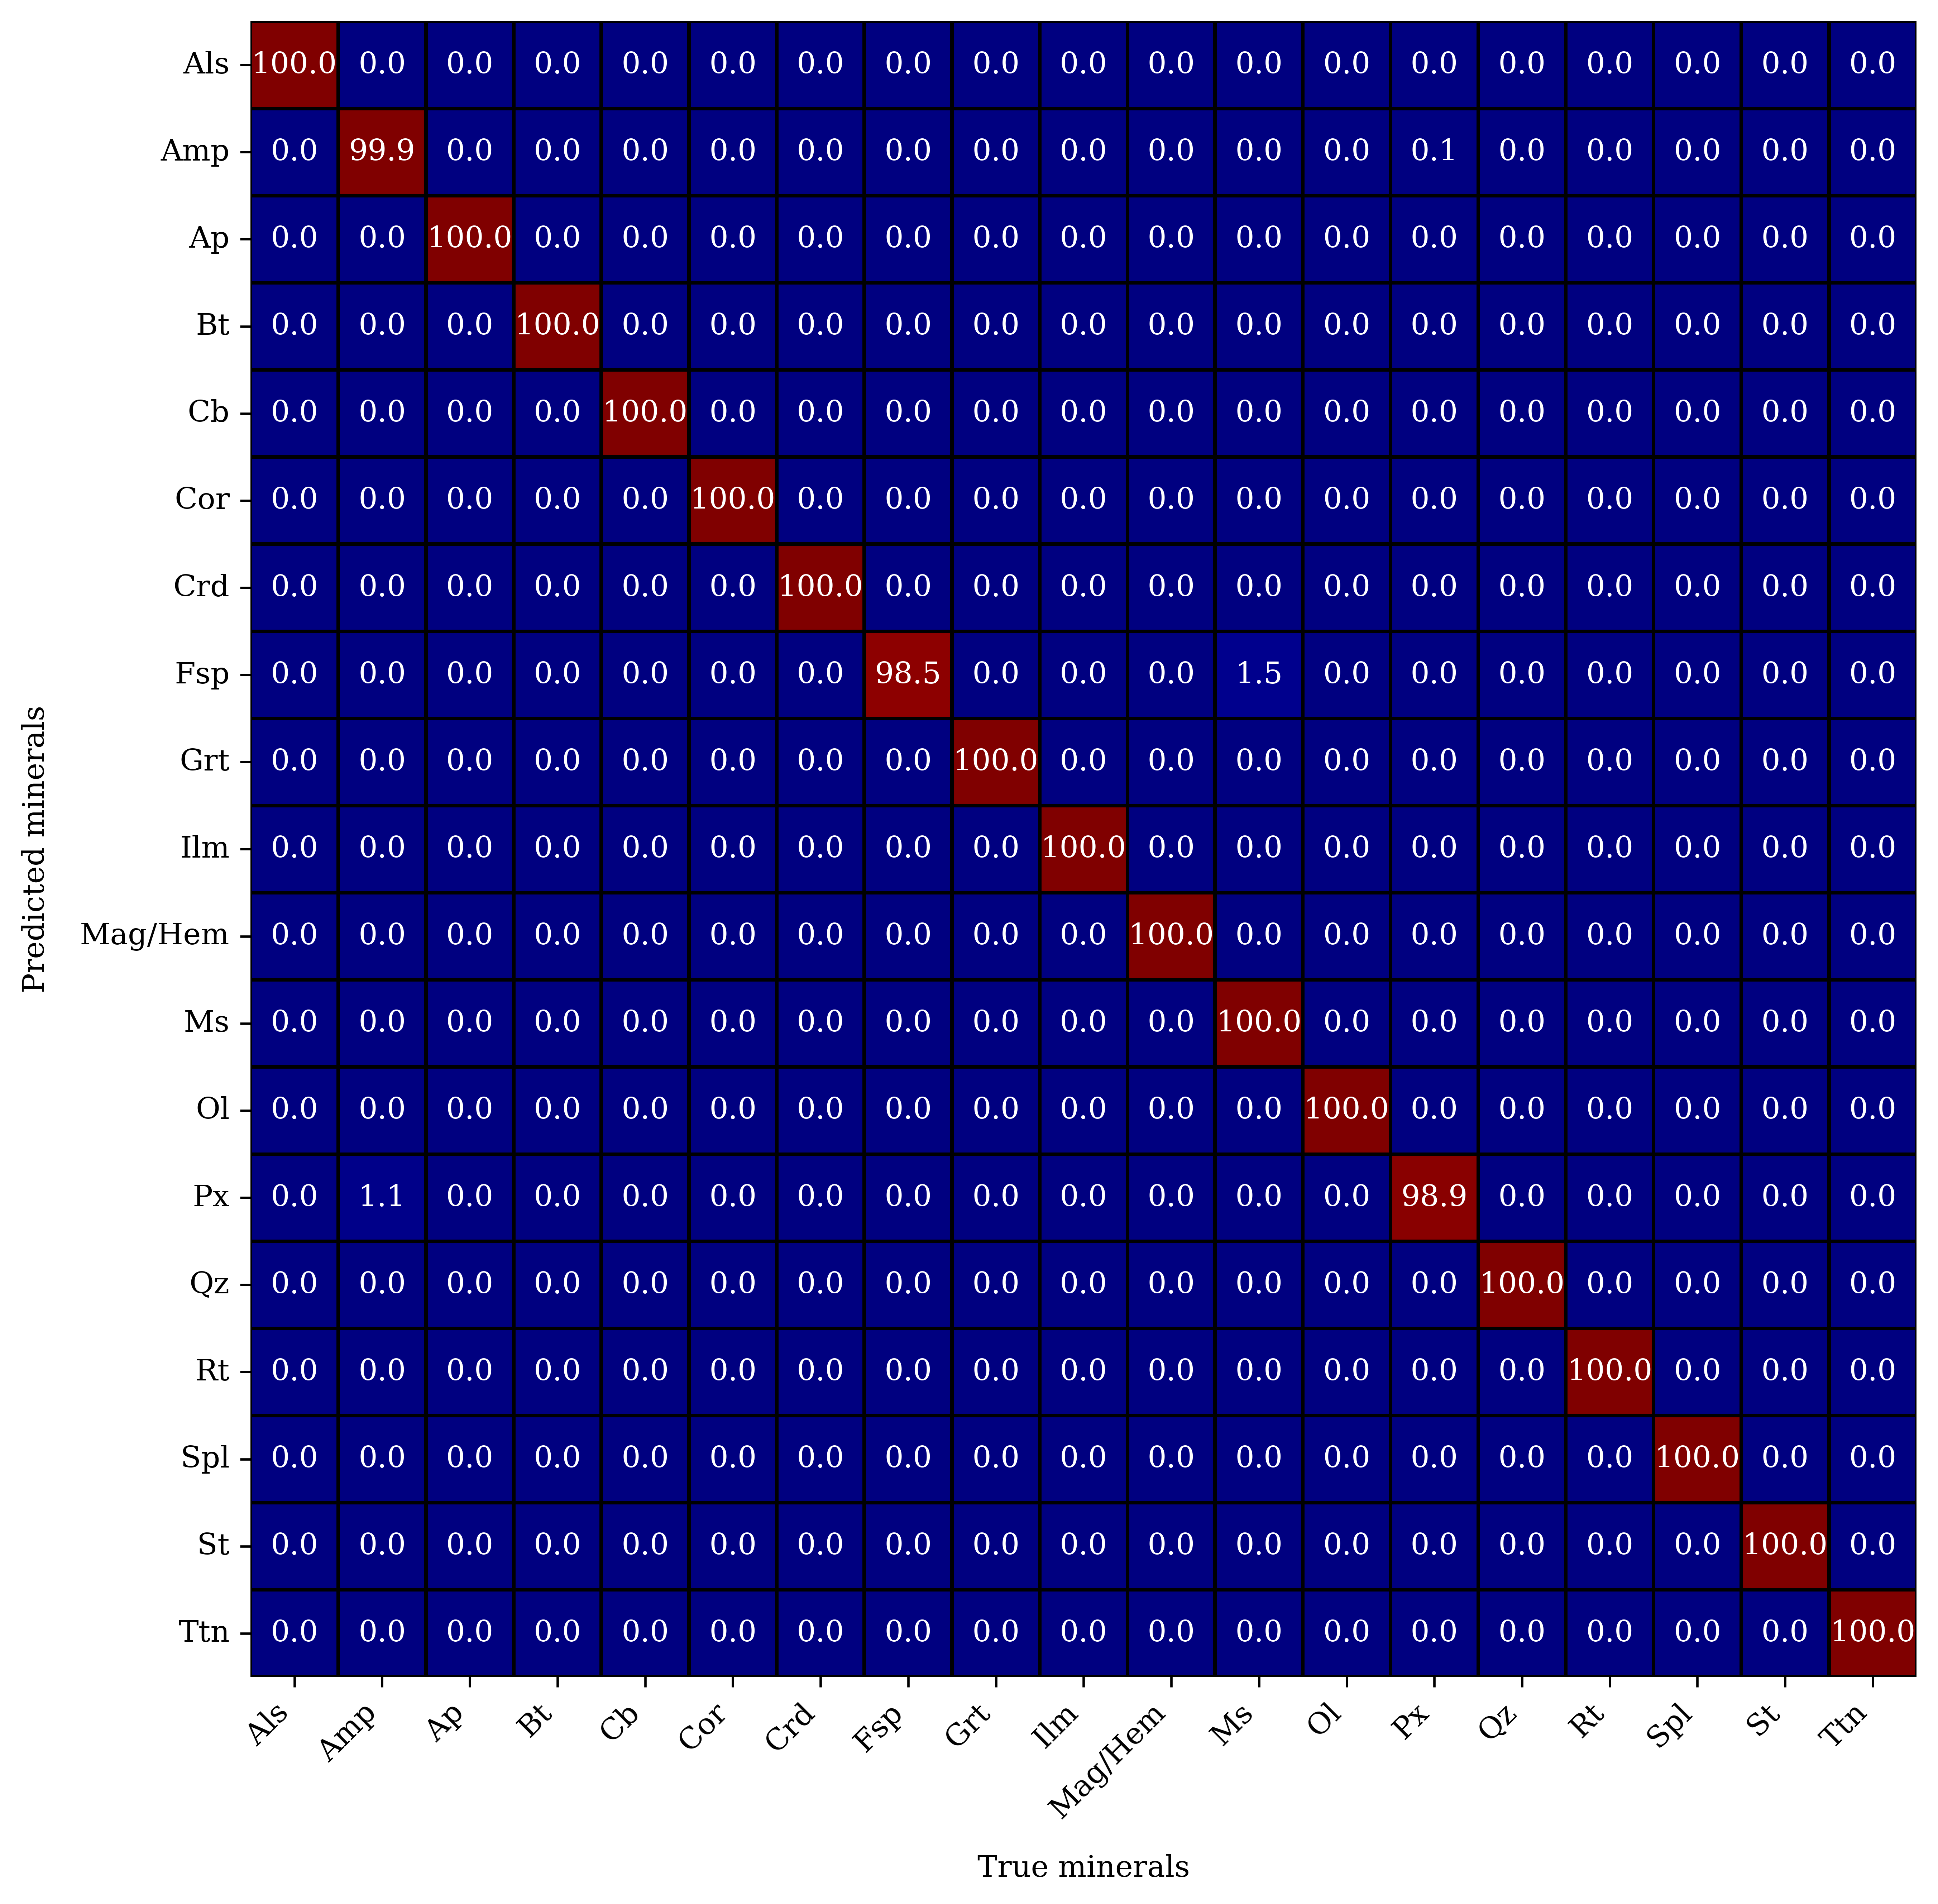

In [12]:
print("\nTesting for FeO+MnO+MgO+CaO and CaO+Na2O+K2O input data\n")

data = data1.copy()
# data =pd.read_excel(file,header=0)

# data.loc[(data.Mineral == "opx") | (data.Mineral == "cpx"),"Mineral"] = "px"

data['M'] = data['FeO']+data['MgO']+data['MnO']+data['CaO']
data.pop("FeO")
data.pop("MgO")
data.pop("MnO")

data['A'] = data["Na2O"]+data['CaO']+data['K2O']
# data['A1'] = data["Na2O"]+data['CaO']
# data['A2'] = data["K2O"]+data["Na2O"]
data.pop("K2O")
data.pop("Na2O")
data.pop("CaO")

data = data[['SiO2', 'TiO2', 'Al2O3', 'M', 'A', 'P2O5', 'CO2', 'Mineral', 'Source']]
# data = data[['SiO2', 'TiO2', 'Al2O3', 'M', 'A1', 'A2', 'P2O5', 'CO2', 'Mineral', 'Source']]


# data['Al/Si'] = (data["Al2O3"]-data['SiO2'])/(data['SiO2']+data['Al2O3'])

# data = data[['SiO2', 'TiO2', 'Al2O3', 'M', 'CaO', 'A', 'Al/Si',
#        'Mineral', 'Source']]
scaler = StandardScaler()
data_scaled = scaler.fit_transform(data.iloc[:,:-2])

labeler = LabelEncoder()
target = labeler.fit_transform(data['Mineral'])

splitter = StratifiedShuffleSplit(n_splits=2,test_size=testsize,random_state=2)
split, split1 = splitter.split(data_scaled, target)
train_data = data_scaled[split1[0],:]
train_label = target[split1[0]]
test_data = data_scaled[split1[1],:]
test_label = target[split1[1]]


# model = svm.SVC(kernel='poly',degree=3,gamma=4,max_iter=1000000,verbose=0)
model.fit(train_data, train_label)
pred_label = model.predict(test_data)
# a = round(f1_score(test_label, pred_label, average="macro"),4)*100
# acc_table[0,3] = a

a = round(f1_score(test_label, pred_label, average=over_metrics),5)*100
r = round(recall_score(test_label, pred_label, average=over_metrics),5)*100
p = round(precision_score(test_label, pred_label, average=over_metrics),5)*100
acc_table[0,3] = a
precision_table[0,3] = p
recall_table[0,3] = r
print(round(a,2))
cm_raw = confusion_matrix(test_label, pred_label,normalize='true')*100
cm_raw = pd.DataFrame(cm_raw,columns = labeler.classes_,index=labeler.classes_)
plt.figure(figsize=figsize,dpi=600)
sns.heatmap(cm_raw, annot=True,cmap="jet",fmt='.1f',linewidths=lw,linecolor='black',cbar=False)
plt.xticks(rotation=45,ha='right')
plt.xlabel("True minerals",labelpad=10)
plt.ylabel("Predicted minerals",labelpad=10)
plt.savefig("SVM_C4.pdf",bbox_inches='tight')

for i in range(0,minerals-1):
    test_data1 = test_data[test_label==i]
    test_label1 = test_label[test_label==i]
    pred_label1 = model.predict(test_data1)
    a = round(f1_score(test_label1, pred_label1, average=sample_metrics),5)*100
    r = round(recall_score(test_label1, pred_label1, average=sample_metrics),5)*100
    p = round(precision_score(test_label1, pred_label1, average=sample_metrics),5)*100
    acc_table[i+1,3] = a
    precision_table[i+1,3] = p
    recall_table[i+1,3] = r
    acc_table[i+1,3] = a
    name = labeler.inverse_transform([i])[0]
    print(f"{name}: accuracy: {a}")
    
pred_label = model.predict(data_scaled)
test_data_df = data.copy()
test_data_df['Pred'] = labeler.inverse_transform(pred_label)
test_data_df_mismatch = test_data_df[test_data_df['Mineral'] != test_data_df['Pred']]
cm = confusion_matrix(target, pred_label)
cm = pd.DataFrame(cm,columns=labeler.classes_,index=labeler.classes_)
test_data_df_mismatch

dump(model,"SVM_C4.mdl")
dump(scaler,"Scaler_C4.scl")
dump(labeler,"Labeler_C4.lbl")

In [13]:
# testres = model.cv_results_
# testres = pd.DataFrame(testres)
# testres.to_excel("/Users/aditya/Documents/Research/Mineral identifier ann IISER Mohali/Additional machine learning algos/SVM/SVM_gridsearch_result_FeO+MnO+MgO+CaO_and_CaO+Na2O+K2O.xlsx")


Testing for PCA (n=5) transformed input data

100.0
Als: accuracy: 100.0
Amp: accuracy: 99.75
Ap: accuracy: 100.0
Bt: accuracy: 99.788
Cb: accuracy: 100.0
Cor: accuracy: 100.0
Crd: accuracy: 100.0
Fsp: accuracy: 100.0
Grt: accuracy: 99.823
Ilm: accuracy: 100.0
Mag/Hem: accuracy: 100.0
Ms: accuracy: 92.512
Ol: accuracy: 100.0
Px: accuracy: 99.18
Qz: accuracy: 100.0
Rt: accuracy: 100.0
Spl: accuracy: 100.0
St: accuracy: 100.0
Ttn: accuracy: 100.0

Testing for PCA (n=6) transformed input data

100.0
Als: accuracy: 100.0
Amp: accuracy: 99.857
Ap: accuracy: 100.0
Bt: accuracy: 99.788
Cb: accuracy: 100.0
Cor: accuracy: 100.0
Crd: accuracy: 100.0
Fsp: accuracy: 100.0
Grt: accuracy: 99.823
Ilm: accuracy: 100.0
Mag/Hem: accuracy: 100.0
Ms: accuracy: 100.0
Ol: accuracy: 100.0
Px: accuracy: 99.18
Qz: accuracy: 100.0
Rt: accuracy: 100.0
Spl: accuracy: 100.0
St: accuracy: 100.0
Ttn: accuracy: 100.0


,SiO2,TiO2,Al2O3,FeO,MnO,MgO,CaO,Na2O,K2O,P2O5,CO2,Mineral,Source,Pred
S No.,,,,,,,,,,,,,,
33701,52.0,0.0,0.0,2.7,0.0,32.3,13.1,0.0,0.0,0.0,0.0,Amp,GEOROC dataset,Px
33110,48.7,0.0,1.6,8.4,0.0,27.0,14.3,0.0,0.0,0.0,0.0,Amp,GEOROC dataset,Px
33109,48.7,0.0,1.7,8.5,0.0,26.9,14.3,0.0,0.0,0.0,0.0,Amp,GEOROC dataset,Px
33105,48.1,2.8,12.6,0.0,0.0,23.0,13.5,0.0,0.0,0.0,0.0,Amp,GEOROC dataset,Grt
33104,48.6,2.3,11.8,0.0,0.0,24.3,13.1,0.0,0.0,0.0,0.0,Amp,GEOROC dataset,Grt
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
30346,51.5,0.0,3.4,2.0,0.0,21.0,22.1,0.0,0.0,0.0,0.0,Px,GEOROC dataset,Amp
30347,51.3,0.0,3.4,2.1,0.0,21.0,22.3,0.0,0.0,0.0,0.0,Px,GEOROC dataset,Amp
30348,50.8,0.0,4.0,2.5,0.0,20.5,22.2,0.0,0.0,0.0,0.0,Px,GEOROC dataset,Amp


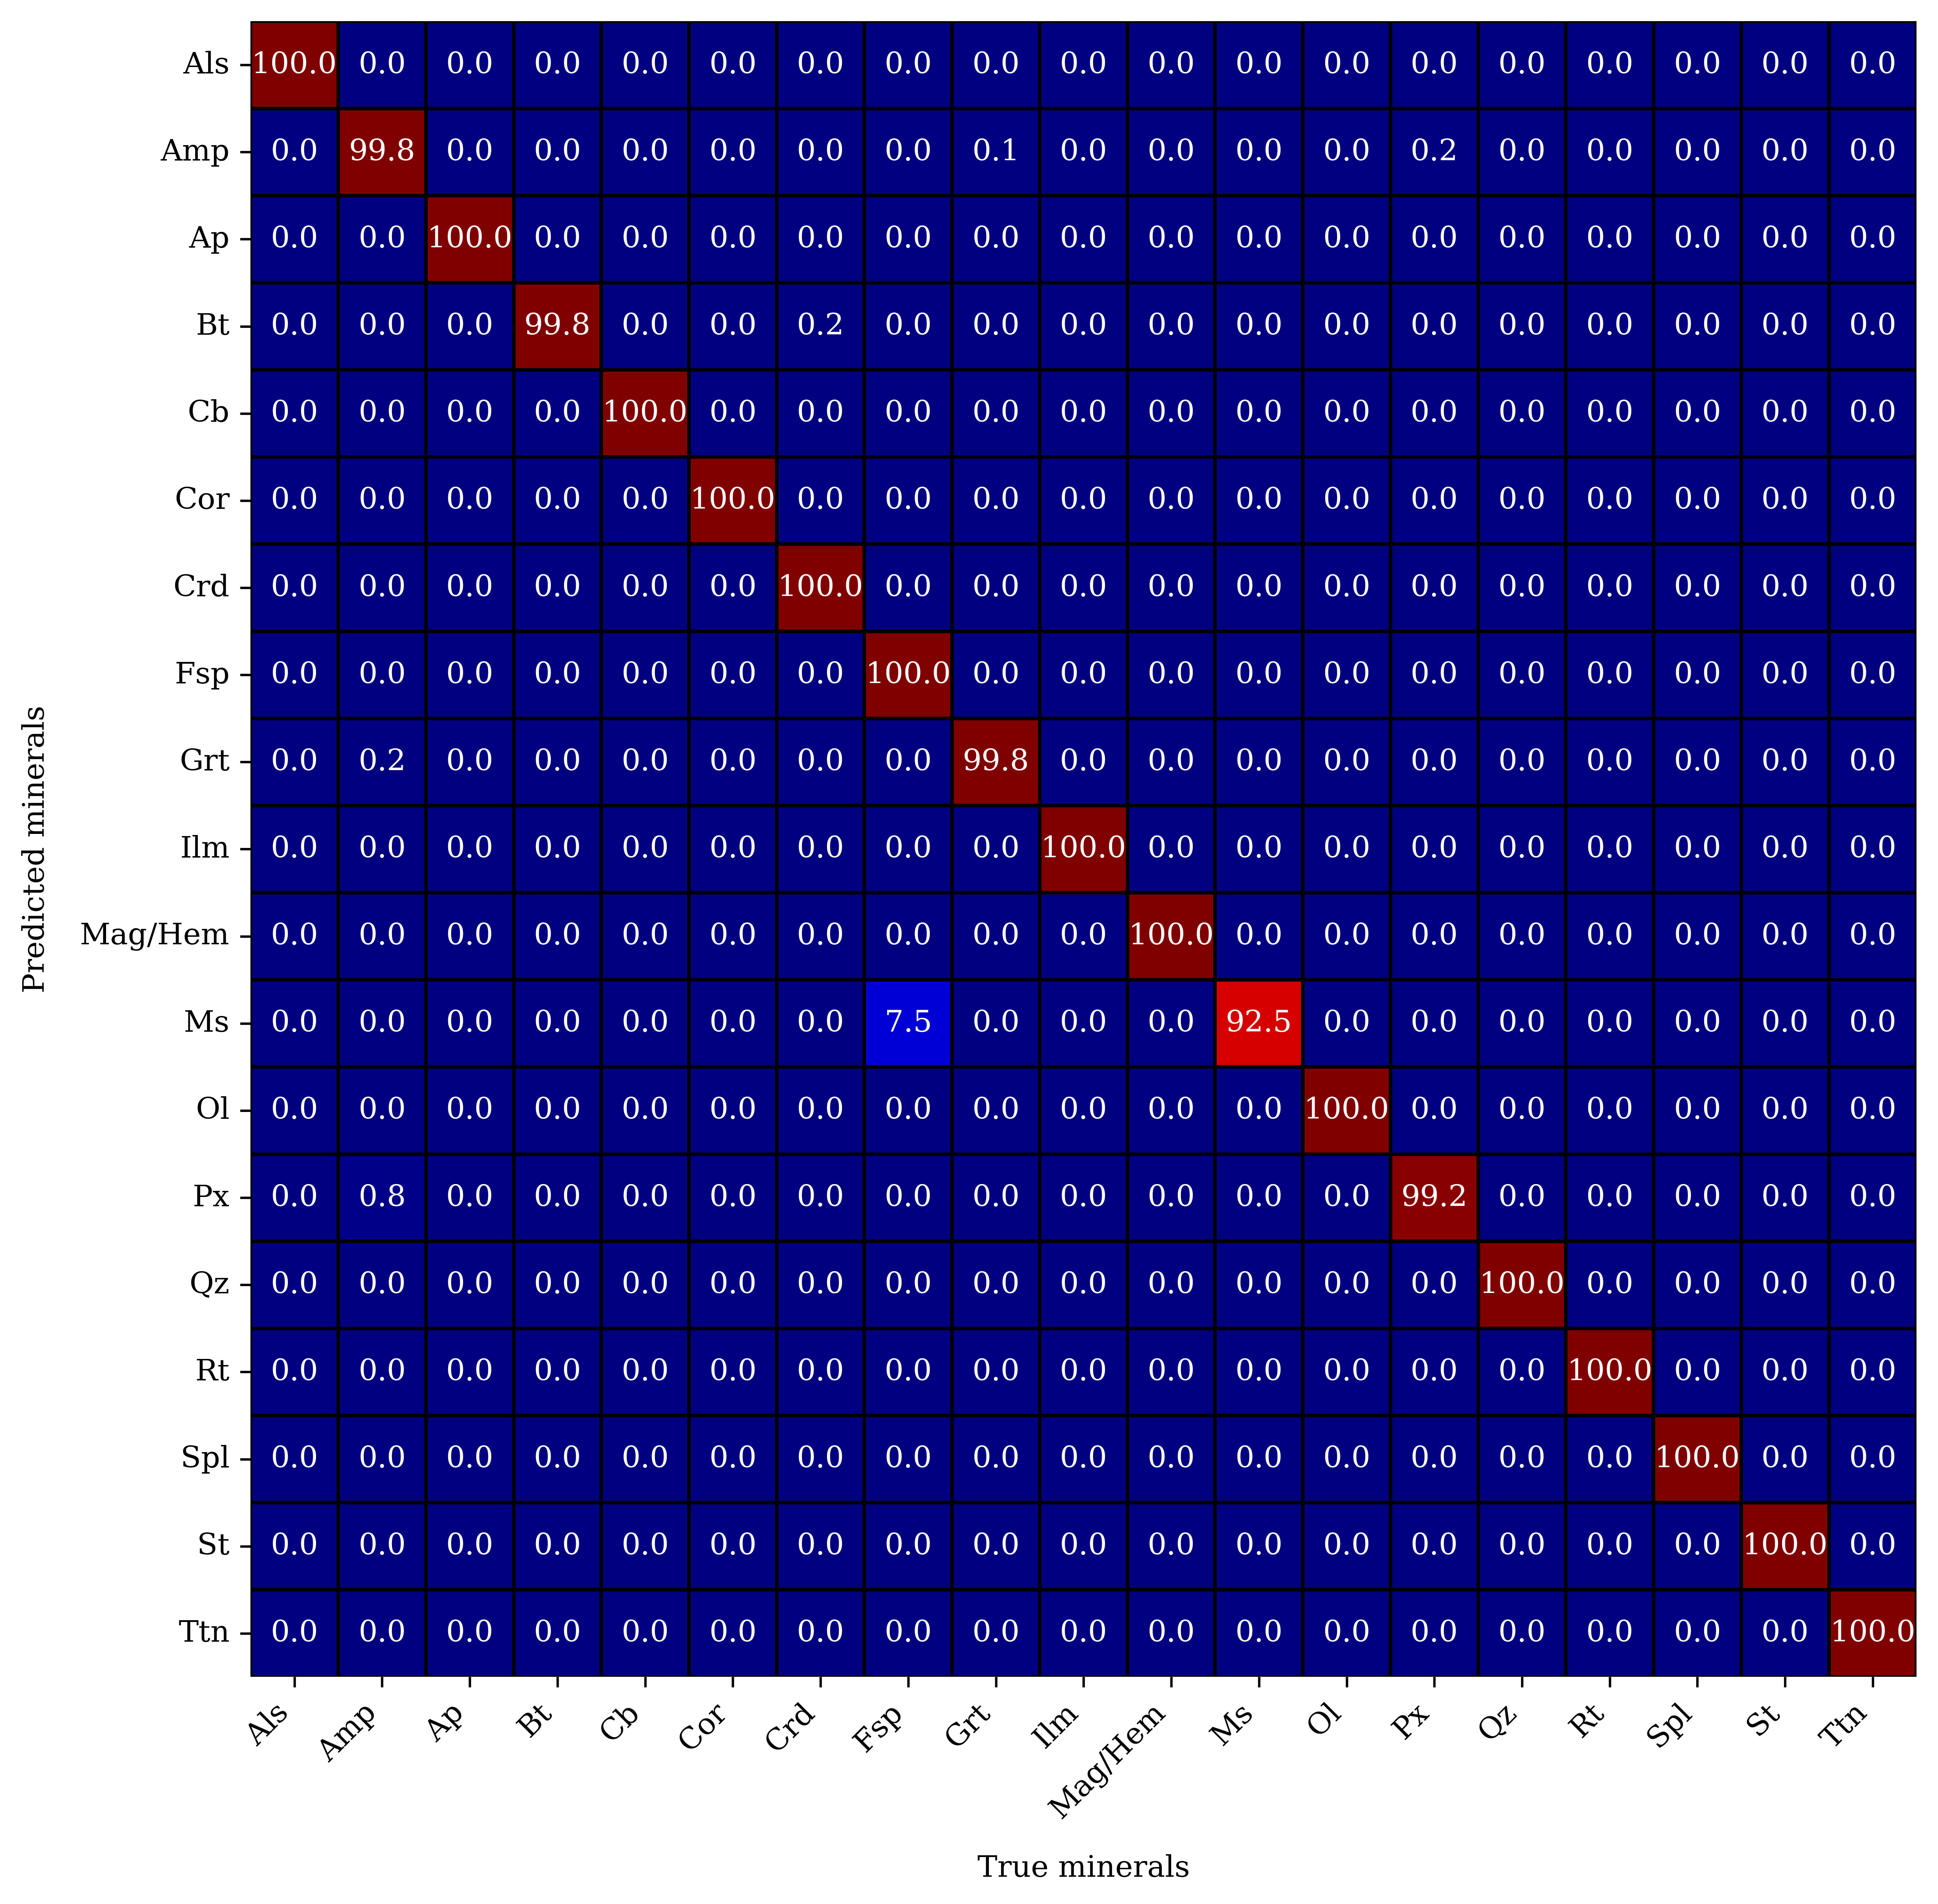

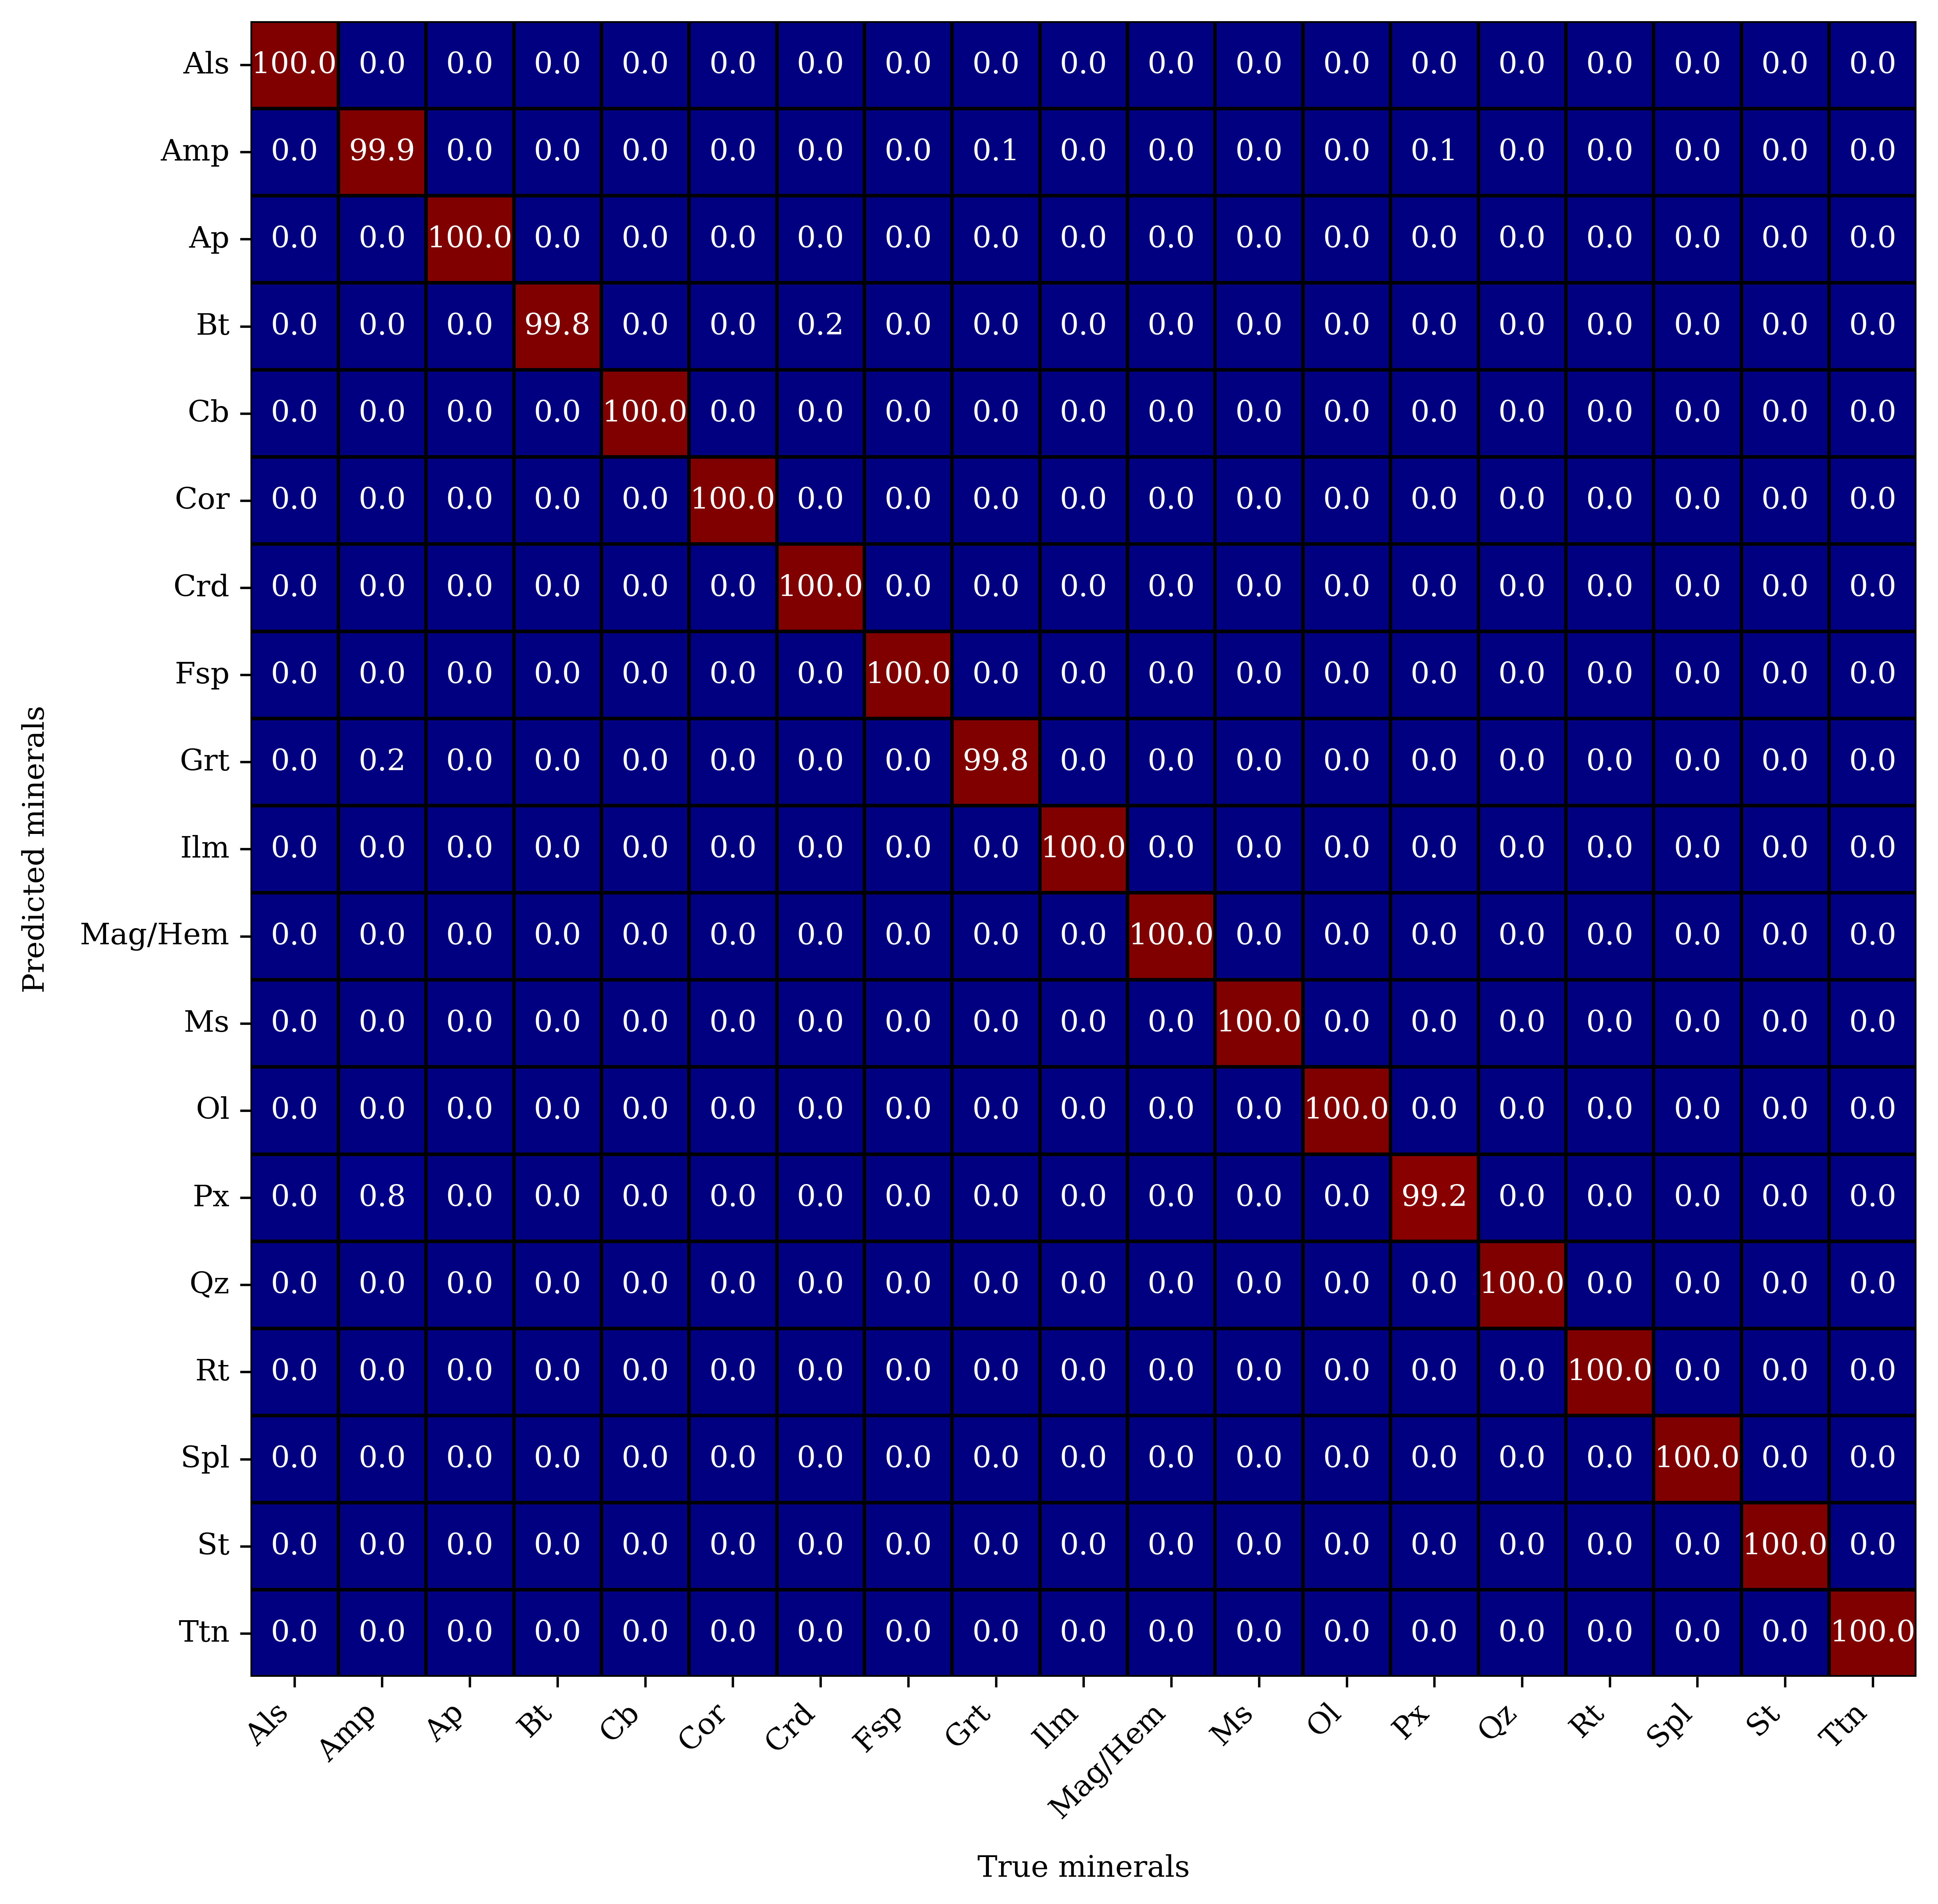

In [14]:
# data =pd.read_excel(file,header=0)
data = data1.copy()
# data.loc[(data.Mineral == "opx") | (data.Mineral == "cpx"),"Mineral"] = "px"
scaler = StandardScaler()
data_scaled = scaler.fit_transform(data.iloc[:,:-2])

labeler = LabelEncoder()
target = labeler.fit_transform(data['Mineral'])

splitter = StratifiedShuffleSplit(n_splits=2,test_size=testsize,random_state=2)
split, split1 = splitter.split(data_scaled, target)
train_data = data_scaled[split1[0],:]
train_label = target[split1[0]]
test_data = data_scaled[split1[1],:]
test_label = target[split1[1]]

for i in range(5,7):
    
    print(f"\nTesting for PCA (n={i}) transformed input data\n")
    data_scaled = data_scaled.copy()
    pca = PCA(n_components=i,svd_solver="full")
    pca_normalized_data = pca.fit_transform(data_scaled)
    train_data = pca_normalized_data[split1[0],:]
    train_label = target[split1[0]]
    test_data = pca_normalized_data[split1[1],:]
    test_label = target[split1[1]]
    # model = svm.SVC(kernel='poly',gamma=3,degree=3,max_iter=1000000,verbose=0,probability=True)
    model.fit(train_data, train_label)
    pred_label = model.predict(test_data)
    # a = round(f1_score(test_label, pred_label, average="macro"),4)*100
    
    a = round(f1_score(test_label1, pred_label1, average=over_metrics),5)*100
    r = round(recall_score(test_label1, pred_label1, average=over_metrics),5)*100
    p = round(precision_score(test_label1, pred_label1, average=over_metrics),5)*100
    acc_table[0,i+3] = a
    precision_table[0,i+3] = p
    recall_table[0,i+3] = r
    print(round(a,2))
    # acc_table[0,i+3] = a
    cm_raw = confusion_matrix(test_label, pred_label,normalize='true')*100
    cm_raw = pd.DataFrame(cm_raw,columns = labeler.classes_,index=labeler.classes_)
    plt.figure(figsize=figsize,dpi=600)
    sns.heatmap(cm_raw, annot=True,cmap="jet",fmt='.1f',linewidths=lw,linecolor='black',cbar=False)
    plt.xticks(rotation=45,ha='right')
    plt.xlabel("True minerals",labelpad=10)
    plt.ylabel("Predicted minerals",labelpad=10)
    plt.savefig(f"SVM_C5(n={i}).pdf",bbox_inches='tight')
     
    for j in range(0,minerals-1):
        test_data1 = test_data[test_label==j]
        test_label1 = test_label[test_label==j]
        pred_label1 = model.predict(test_data1)
        a = round(f1_score(test_label1, pred_label1, average="micro"),4)*100
        acc_table[j+1,i+3] = a
        
        a = round(f1_score(test_label1, pred_label1, average=sample_metrics),5)*100
        r = round(recall_score(test_label1, pred_label1, average=sample_metrics),5)*100
        p = round(precision_score(test_label1, pred_label1, average=sample_metrics),5)*100
        acc_table[j+1,i+3] = a
        precision_table[j+1,i+3] = p
        recall_table[j+1,i+3] = r
        acc_table[j+1,i+3] = a
        name = labeler.inverse_transform([j])[0]
        print(f"{name}: accuracy: {a}")
    dump(model,"SVM_C5_"+str(i)+"_components.mdl")
    dump(scaler,"Scaler_C5_"+str(i)+"_components.scl")
    dump(labeler,"Labeler_C5_"+str(i)+"_components.lbl")
    dump(pca,"PCA_C5_"+str(i)+"_components.pc")
data_scaled1 = pca.transform(data_scaled)
pred_label = model.predict(data_scaled1)
test_data_df = data.copy()
test_data_df['Pred'] = labeler.inverse_transform(pred_label)
test_data_df_mismatch = test_data_df[test_data_df['Mineral'] != test_data_df['Pred']]
test_data_df_mismatch

In [15]:
l = ["Overall"]
l.extend([i for i in labeler.classes_])
# acc_table = pd.DataFrame(acc_table,
#                           columns=["Raw Input", "FeO+MnO+MgO combined", "FeO+MnO+MgO+CaO & Na2O+K2O combined", "FeO+MnO+MgO+CaO & Na2O+K2O+CaO combined", "PCA (n=1) transformed", "PCA (n=2) transformed", "PCA (n=3) transformed", "PCA (n=4) transformed", "PCA (n=5) transformed", "PCA (n=6) transformed", "PCA (n=7) transformed", "PCA (n=8) transformed"],
#                           index=["Overall", "Als", "Amp", "Ap", "Bt","Crd", 
#                                  "Fsp", "Grt", "Ilm","Mag", 'Ms','Ol','Pg',
#                                  'Px',"Qz",'Rt', 'Spl', 'St', 'Ttn'])
acc_table = pd.DataFrame(acc_table,
                          columns=["Raw Input", "FeO+MnO+MgO combined", "FeO+MnO+MgO & Na2O+K2O combined", "FeO+MnO+MgO+CaO & Na2O+K2O+CaO combined", "PCA (n=1) transformed", "PCA (n=2) transformed", "PCA (n=3) transformed", "PCA (n=4) transformed", "PCA (n=5) transformed", "PCA (n=6) transformed", "PCA (n=7) transformed", "PCA (n=8) transformed", "PCA (n=9) transformed", "PCA (n=10) transformed"],
                          index=l)
recall_table = pd.DataFrame(recall_table,
                          columns=["Raw Input", "FeO+MnO+MgO combined", "FeO+MnO+MgO & Na2O+K2O combined", "FeO+MnO+MgO+CaO & Na2O+K2O+CaO combined", "PCA (n=1) transformed", "PCA (n=2) transformed", "PCA (n=3) transformed", "PCA (n=4) transformed", "PCA (n=5) transformed", "PCA (n=6) transformed", "PCA (n=7) transformed", "PCA (n=8) transformed", "PCA (n=9) transformed", "PCA (n=10) transformed"],
                          index=l)

precision_table = pd.DataFrame(precision_table,
                          columns=["Raw Input", "FeO+MnO+MgO combined", "FeO+MnO+MgO & Na2O+K2O combined", "FeO+MnO+MgO+CaO & Na2O+K2O+CaO combined", "PCA (n=1) transformed", "PCA (n=2) transformed", "PCA (n=3) transformed", "PCA (n=4) transformed", "PCA (n=5) transformed", "PCA (n=6) transformed", "PCA (n=7) transformed", "PCA (n=8) transformed", "PCA (n=9) transformed", "PCA (n=10) transformed"],
                          index=l)

In [16]:
# path = "/Users/aditya/Documents/Research/Mineral\ identifier\ ann\ IISER\ Mohali/Additional\ machine\ learning\ algos/SVM/"
# path=""

# acc_table.to_excel(path+r"F1-score Accuracy report for SVM.xlsx")
# # acc_table.to_excel(r"/home/avi/Documents/Research/Mineral identifier ann IISER Mohali/Additional machine learning algos/SVM/F1-score Accuracy report for SVM_withoutamph.xlsx")
# recall_table.to_excel(path+r"Recall-score Accuracy report for SVM.xlsx")
# precision_table.to_excel(path+r"Precision-score Accuracy report for SVM.xlsx")

In [17]:
# model.cv_results_[mean_score

In [18]:
# joblib.dump(model,"model_01042024.pkl")
# joblib.dump(scaler,"scaler_01042024.pkl")
# joblib.dump(labeler,"labelencoder_01042024.pkl")